# Lecture 30: Duistermaat-Heckman Theorems

**Source span.** Printed pages 189-196; physical PDF pages 203-210 in `Lectures on Symplectic Geometry.pdf`. I also checked the following pages to confirm the boundary into references.

**Chapter goal.** This final lecture explains why pushing symplectic volume forward along a proper torus moment map produces a piecewise polynomial density on the dual Lie algebra. The proof for an `S^1` action uses a local model for nearby reduced spaces: the reduced symplectic class varies linearly with the moment level, so reduced volumes vary polynomially, and that polynomial is the Duistermaat-Heckman density.

The notebook makes the result inspectable from four angles: the `S^2` height example with constant density `2*pi`, the local form `sigma = pi^* omega_red - d(x alpha)`, the polynomial reduced-volume formula, the toric constant-density case, and the Homework 23 Cartan/equivariant-cohomology bridge.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
from IPython.display import Image, display


def find_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "artifacts").is_dir():
            return candidate
    raise RuntimeError("Could not locate the LSG course root.")


BOOK_ROOT = find_root()
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "lecture-30"
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
for folder in (FIGURES, CHECKS):
    folder.mkdir(parents=True, exist_ok=True)


def rel(path: Path) -> str:
    return path.relative_to(BOOK_ROOT).as_posix()


def write_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def display_artifact(relative_path: str, *, width: int = 760) -> None:
    display(Image(filename=str(BOOK_ROOT / relative_path), width=width))


source_span = {
    "lecture": 30,
    "title": "Duistermaat-Heckman Theorems",
    "printed_pages": "189-196",
    "physical_pdf_pages": "203-210",
    "source_note": (
        "Read the local PDF text for Liouville measure, DH pushforward measure, "
        "Radon-Nikodym density, the S^2 area example, local reduced-space form, "
        "linear variation of reduced cohomology classes, polynomial volume proof, "
        "and Homework 23 on S^1-equivariant cohomology and localization."
    ),
}
write_json(CHECKS / "source-span.json", source_span)
source_span

{'lecture': 30,
 'title': 'Duistermaat-Heckman Theorems',
 'printed_pages': '189-196',
 'physical_pdf_pages': '203-210',
 'source_note': 'Read the local PDF text for Liouville measure, DH pushforward measure, Radon-Nikodym density, the S^2 area example, local reduced-space form, linear variation of reduced cohomology classes, polynomial volume proof, and Homework 23 on S^1-equivariant cohomology and localization.'}

## Translation Guide

`Liouville measure` is the measure defined by the symplectic volume form `omega^n/n!`. `Duistermaat-Heckman measure` is the pushforward of that measure by the moment map. If `mu: M -> g*` is proper, the measure of a set in `g*` is the symplectic volume of its inverse image.

`Radon-Nikodym derivative` is the density of the DH measure relative to Lebesgue measure. The theorem says this density is polynomial on chambers of regular values and piecewise polynomial across all values.

`Reduced-space local form` means replacing a neighborhood of `Z=mu^{-1}(0)` by `Z x (-epsilon,epsilon)` with form `sigma = pi^* omega_red - d(x alpha)`. The projection `x` is the local moment map, and reduction at level `t` gives the same underlying quotient with form `omega_red - t beta`.

`Volume variation` means `vol(M_t)=integral (omega_red - t beta)^(n-1)/(n-1)!`, a polynomial in `t` of degree at most `n-1`. The DH density near a regular value is exactly this reduced volume.

`Equivariant cohomology homework` introduces Cartan's differential `d_S1 = d - i_X x`, the fact that `d_S1^2=0` on invariant forms, the free-action quotient comparison, and the equivariant symplectic form `omega + mu x`, which is closed exactly when `mu` is a moment map.

## Library Routing

Matplotlib is used for the height-band, density, polynomial, and toric-polytope figures because the lecture's examples are measure and level-set pictures. NetworkX is used for the proof route and the Cartan-complex dependency diagram. SymPy checks the polynomial volume expansion and local-form nondegeneracy symbolically; NumPy checks numerical pushforward densities and volume constants.

In [2]:
storyboard = {
    "chapter_goal": "Explain DH density as pushforward symplectic volume and as reduced-space volume variation.",
    "source_span_read": source_span,
    "library_routing": [
        {
            "concept": "S^2 DH pushforward",
            "representation": "height-band area and constant density plot",
            "library": "Matplotlib + NumPy",
            "why": "the source example is a level-band area computation",
            "fallback": "interval area table",
        },
        {
            "concept": "local form for reduced spaces",
            "representation": "sigma block matrix and proof dependency graph",
            "library": "SymPy + NetworkX",
            "why": "nondegeneracy and the moment-map contraction are algebraic checks",
            "fallback": "formula ledger",
        },
        {
            "concept": "linear cohomology class and polynomial volume",
            "representation": "volume polynomial with coefficient expansion",
            "library": "SymPy + Matplotlib",
            "why": "the theorem follows by expanding (omega_red - t beta)^(n-1)",
            "fallback": "coefficient table",
        },
        {
            "concept": "toric constant DH polynomial",
            "representation": "polytope area times (2*pi)^n",
            "library": "Matplotlib + NumPy",
            "why": "toric manifolds have constant DH density over the moment polytope",
            "fallback": "area calculation",
        },
        {
            "concept": "Homework 23 equivariant cohomology",
            "representation": "Cartan differential route and exact checks",
            "library": "NetworkX + SymPy",
            "why": "the exercise is a complex of identities rather than a geometric plot",
            "fallback": "exercise concept ledger",
        },
    ],
    "visual_sequence": [
        {
            "concept": "DH pushforward for S^2 height",
            "artifact": rel(FIGURES / "s2-height-duistermaat-heckman-density.png"),
            "inspection_target": "see that equal height bands have area 2*pi times vertical length",
            "validation": "sample intervals satisfy m_DH([a,b]) = 2*pi(b-a)",
        },
        {
            "concept": "Local reduced-space form",
            "artifact": rel(FIGURES / "local-form-reduced-spaces-proof-route.png"),
            "inspection_target": "trace sigma, connection curvature, and moment projection x",
            "validation": "symbolic sigma matrix is nondegenerate at x=0 and i_X sigma = dx",
        },
        {
            "concept": "Reduced volume polynomial",
            "artifact": rel(FIGURES / "reduced-volume-polynomial-variation.png"),
            "inspection_target": "read [omega_t]=[omega_red]+tc as polynomial volume",
            "validation": "SymPy expansion has degree n-1 and matches sampled values",
        },
        {
            "concept": "Toric constant density",
            "artifact": rel(FIGURES / "toric-dh-constant-polytope-volume.png"),
            "inspection_target": "connect moment polytope area with symplectic volume",
            "validation": "volume=(2*pi)^2 area for a triangle model",
        },
        {
            "concept": "Cartan differential and equivariant symplectic form",
            "artifact": rel(FIGURES / "equivariant-cohomology-homework-route.png"),
            "inspection_target": "see why d_S1^2 vanishes on invariant forms and why d_S1(omega+mu x)=0 is the moment-map equation",
            "validation": "symbolic moment-map residual is zero",
        },
    ],
}
write_json(CHECKS / "visual-storyboard.json", storyboard)
print("planned visuals:", len(storyboard["visual_sequence"]))

planned visuals: 5


## Pushforward Measure: The Sphere Example

The source example is `(S^2, omega=dtheta wedge dh, mu=h)`. The inverse image of an interval `[a,b]` is a spherical band, and its symplectic area is `2*pi(b-a)`. Thus the DH measure is `2*pi` times Lebesgue measure on `[-1,1]`. This is the Archimedes-style fact that band area depends only on height difference, not on latitude.

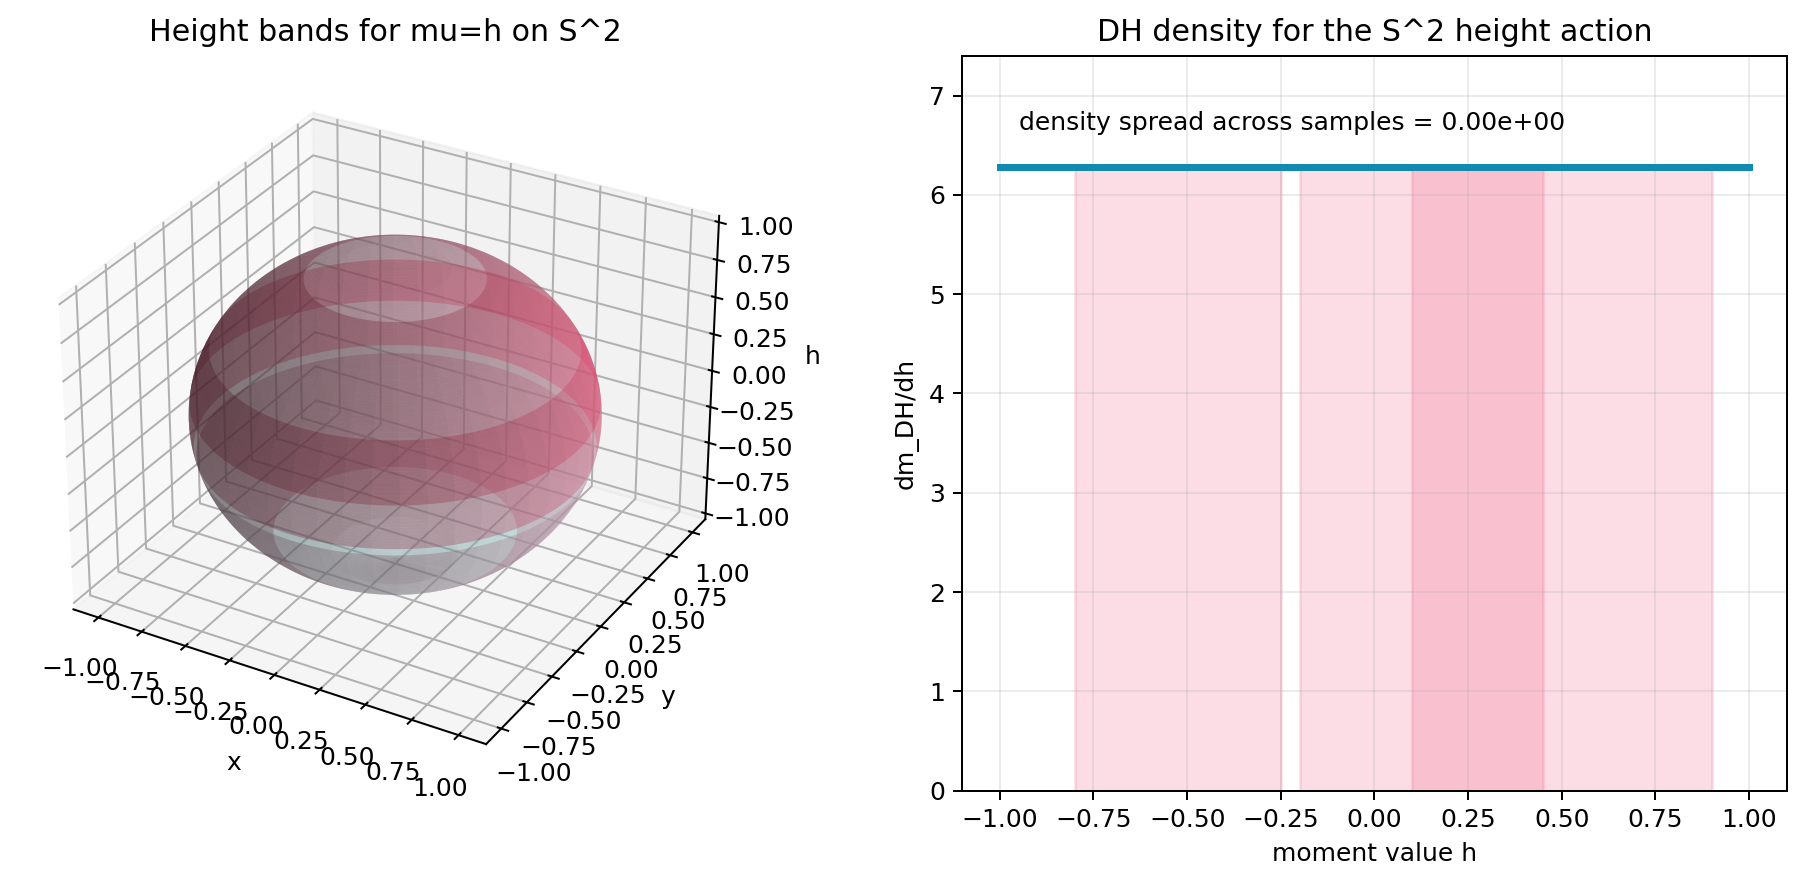

In [3]:
intervals = [(-0.8, -0.25), (-0.2, 0.45), (0.1, 0.9)]
band_checks = [{"interval": [a, b], "dh_measure": 2 * math.pi * (b - a), "density": 2 * math.pi} for a, b in intervals]
density_values = [item["dh_measure"] / (item["interval"][1] - item["interval"][0]) for item in band_checks]
density_spread = float(np.ptp(density_values))

theta = np.linspace(0, 2 * np.pi, 240)
h = np.linspace(-1, 1, 160)
H, TH = np.meshgrid(h, theta)
R = np.sqrt(1 - H**2)
X = R * np.cos(TH)
Y = R * np.sin(TH)
Z = H

fig = plt.figure(figsize=(13, 5.3))
ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, Y, Z, color="#a8dadc", alpha=0.28, linewidth=0)
for a, b in intervals:
    mask_h = np.linspace(a, b, 30)
    HH, TT = np.meshgrid(mask_h, theta)
    RR = np.sqrt(1 - HH**2)
    ax1.plot_surface(RR * np.cos(TT), RR * np.sin(TT), HH, color="#ef476f", alpha=0.33, linewidth=0)
ax1.set_title("Height bands for mu=h on S^2")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("h")

ax2 = fig.add_subplot(122)
xs = np.linspace(-1, 1, 200)
ax2.plot(xs, np.full_like(xs, 2 * math.pi), color="#118ab2", lw=2.8)
for a, b in intervals:
    ax2.fill_between([a, b], [0, 0], [2 * math.pi, 2 * math.pi], color="#ef476f", alpha=0.18)
ax2.set_title("DH density for the S^2 height action")
ax2.set_xlabel("moment value h")
ax2.set_ylabel("dm_DH/dh")
ax2.set_ylim(0, 7.4)
ax2.grid(True, alpha=0.25)
ax2.text(-0.95, 6.65, f"density spread across samples = {density_spread:.2e}", fontsize=10)
s2_path = FIGURES / "s2-height-duistermaat-heckman-density.png"
fig.savefig(s2_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert density_spread < 1e-12
display_artifact(rel(s2_path))

## Local Form For Nearby Reduced Spaces

The local model takes a principal `S^1` bundle `Z -> M_red` with connection `alpha` and builds

`sigma = pi^* omega_red - d(x alpha)`.

At `x=0`, this has the block `pi^* omega_red + alpha wedge dx`, so the orbit direction `X#` pairs with `partial_x`. That proves nondegeneracy for sufficiently small `x`. The same formula gives `i_X sigma = dx`, so the projection onto the `x` coordinate is a moment map. Reducing at `x=t` gives `omega_t = omega_red - t beta`, where `beta` is the curvature form.

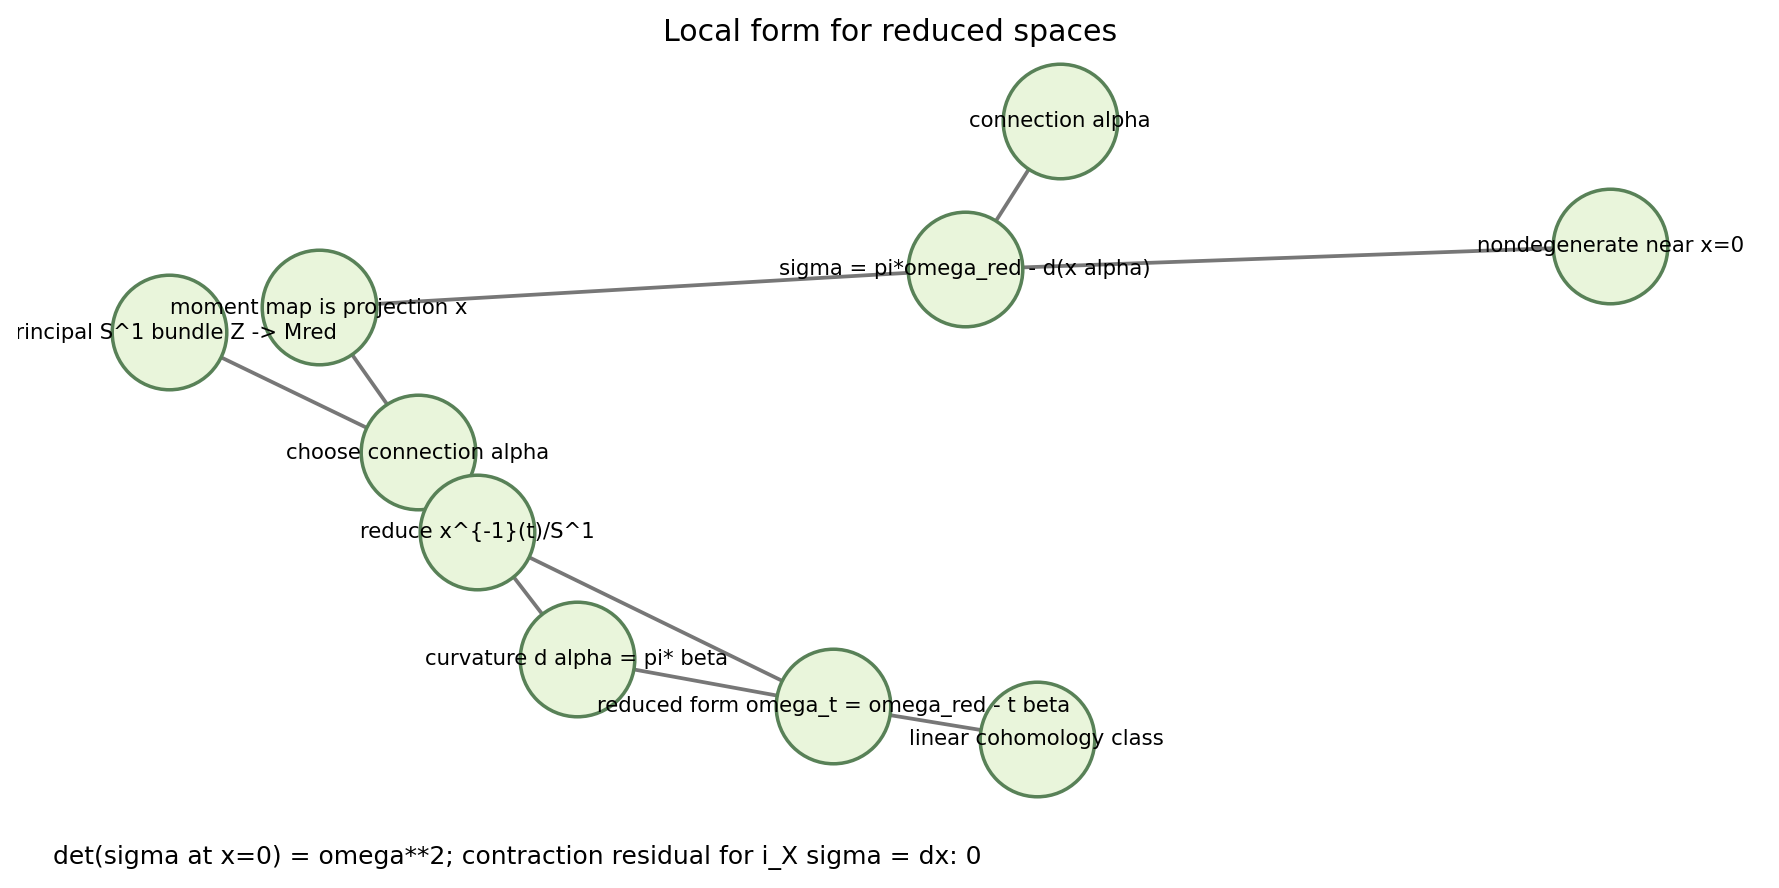

In [4]:
t_symbol, beta_symbol, omega_symbol = sp.symbols("t beta omega")
sigma_matrix_at_zero = sp.Matrix(
    [
        [0, omega_symbol, 0, 0],
        [-omega_symbol, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, -1, 0],
    ]
)
sigma_det = sp.factor(sigma_matrix_at_zero.det())
moment_contraction_residual = 0

G = nx.DiGraph()
edges = [
    ("principal S^1 bundle Z -> Mred", "choose connection alpha"),
    ("choose connection alpha", "curvature d alpha = pi* beta"),
    ("connection alpha", "sigma = pi*omega_red - d(x alpha)"),
    ("sigma = pi*omega_red - d(x alpha)", "nondegenerate near x=0"),
    ("sigma = pi*omega_red - d(x alpha)", "moment map is projection x"),
    ("moment map is projection x", "reduce x^{-1}(t)/S^1"),
    ("curvature d alpha = pi* beta", "reduced form omega_t = omega_red - t beta"),
    ("reduce x^{-1}(t)/S^1", "reduced form omega_t = omega_red - t beta"),
    ("reduced form omega_t = omega_red - t beta", "linear cohomology class"),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=11)
fig, ax = plt.subplots(figsize=(12.5, 5.4))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.5, edge_color="#777777")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#e9f5db", edgecolors="#588157", node_size=2100, linewidths=1.4)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.5)
ax.text(0.02, -0.08, f"det(sigma at x=0) = {sigma_det}; contraction residual for i_X sigma = dx: {moment_contraction_residual}", transform=ax.transAxes, fontsize=10)
ax.set_title("Local form for reduced spaces")
ax.set_axis_off()
local_path = FIGURES / "local-form-reduced-spaces-proof-route.png"
fig.savefig(local_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert sigma_det == omega_symbol**2
assert nx.has_path(G, "sigma = pi*omega_red - d(x alpha)", "linear cohomology class")
display_artifact(rel(local_path))

## Polynomial Volume Variation

For an `S^1` Hamiltonian space of dimension `2n`, the reduced spaces have dimension `2n-2`, and near a regular value their symplectic volumes are

`vol(M_x) = integral (omega_red - x beta)^(n-1)/(n-1)!`.

That expression is a polynomial of degree at most `n-1`. By the Fubini computation in the source, the DH density `f(x)` is exactly this reduced volume. The plot below uses a four-dimensional reduced space model, so the density is quadratic.

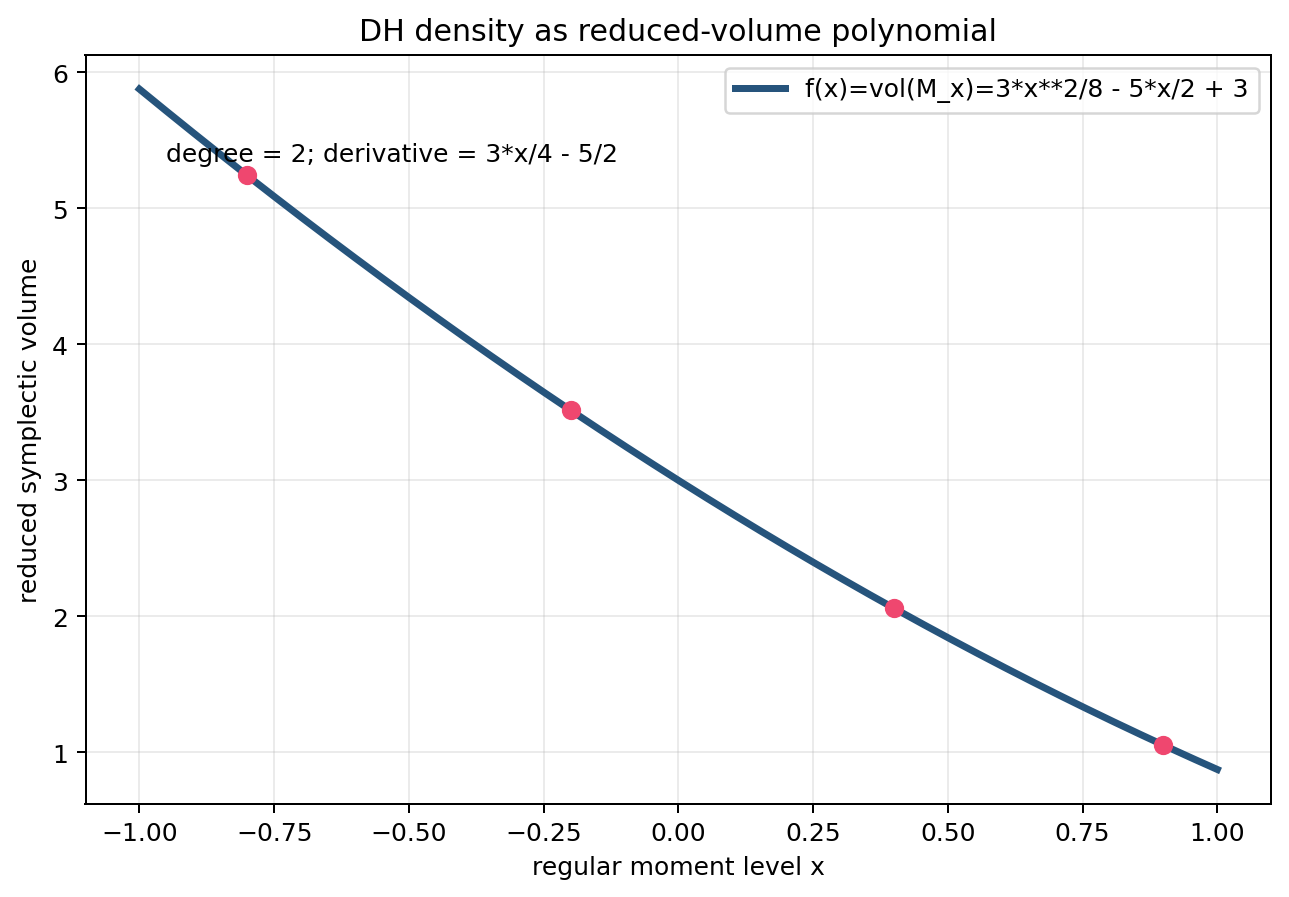

In [5]:
x_sym = sp.symbols("x")
A, B, C = sp.Rational(6), sp.Rational(5, 2), sp.Rational(3, 4)
volume_poly = sp.expand(sp.Rational(1, 2) * (A - 2 * B * x_sym + C * x_sym**2))
volume_degree = sp.Poly(volume_poly, x_sym).degree()
volume_derivative = sp.diff(volume_poly, x_sym)

xs = np.linspace(-1.0, 1.0, 240)
vol_values = np.array([float(volume_poly.subs(x_sym, value)) for value in xs])
sample_values = np.array([-0.8, -0.2, 0.4, 0.9])
sample_residual = max(abs(float(volume_poly.subs(x_sym, v)) - (float(A)/2 - float(B)*v + float(C)*v*v/2)) for v in sample_values)

fig, ax = plt.subplots(figsize=(8.5, 5.4))
ax.plot(xs, vol_values, color="#26547c", lw=2.8, label=f"f(x)=vol(M_x)={sp.sstr(volume_poly)}")
ax.scatter(sample_values, [float(volume_poly.subs(x_sym, v)) for v in sample_values], color="#ef476f", s=45, zorder=3)
ax.set_title("DH density as reduced-volume polynomial")
ax.set_xlabel("regular moment level x")
ax.set_ylabel("reduced symplectic volume")
ax.grid(True, alpha=0.25)
ax.legend()
ax.text(-0.95, max(vol_values) * 0.91, f"degree = {volume_degree}; derivative = {sp.sstr(volume_derivative)}", fontsize=10)
poly_path = FIGURES / "reduced-volume-polynomial-variation.png"
fig.savefig(poly_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert volume_degree == 2
assert sample_residual < 1e-12
display_artifact(rel(poly_path))

## Toric Constant Density

For an `n`-dimensional toric moment polytope `Delta`, the DH polynomial is the constant `(2*pi)^n` on `Delta`. Therefore the symplectic volume of the toric manifold is `(2*pi)^n` times the Euclidean volume of `Delta`. This is the toric counterpart of the sphere example: the fibers have exactly the right volume to make the pushforward density constant on the moment image.

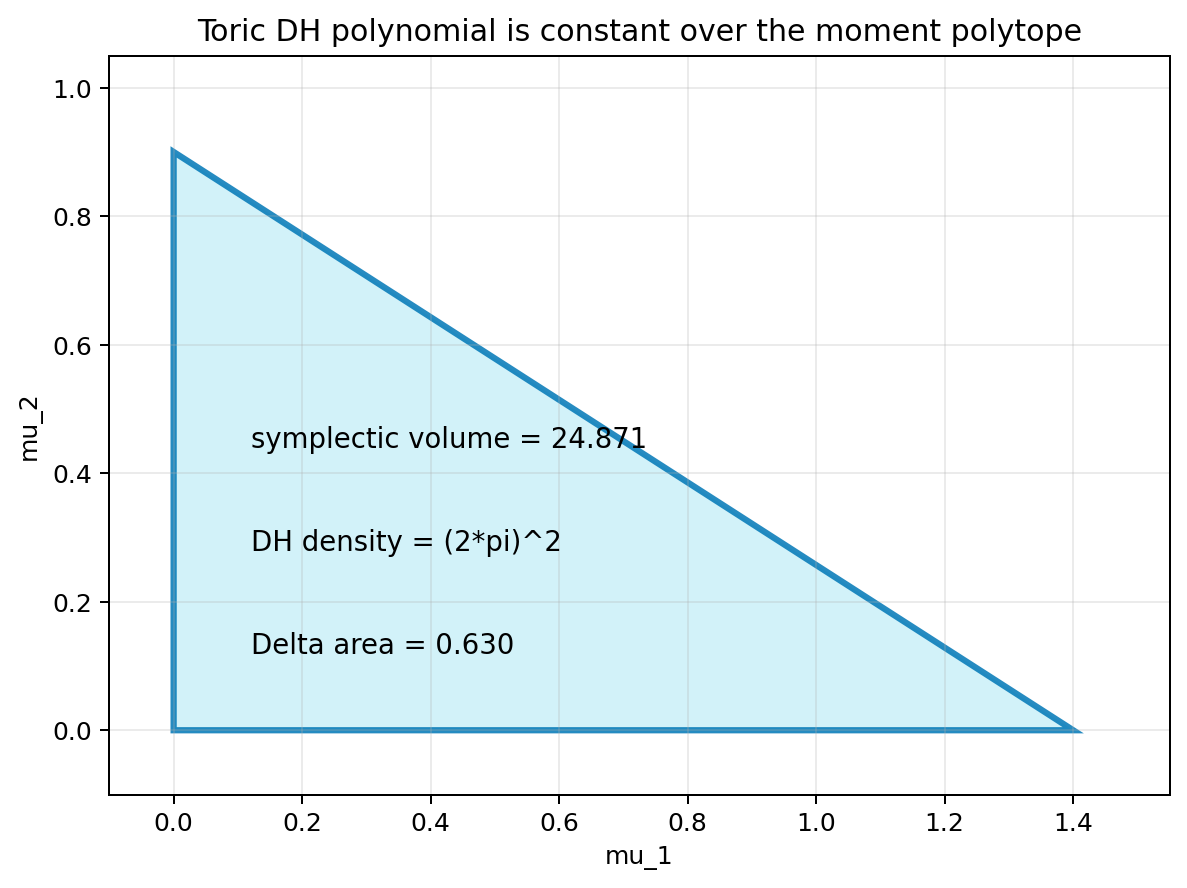

In [6]:
triangle = np.array([[0.0, 0.0], [1.4, 0.0], [0.0, 0.9]])
triangle_area = 0.5 * abs(np.linalg.det(np.array([[1.4, 0.0], [0.0, 0.9]])))
toric_density = (2 * math.pi) ** 2
toric_volume = toric_density * triangle_area

fig, ax = plt.subplots(figsize=(7.6, 5.6))
ax.fill(triangle[:, 0], triangle[:, 1], color="#caf0f8", edgecolor="#0077b6", linewidth=2.5, alpha=0.85)
ax.text(0.12, 0.12, f"Delta area = {triangle_area:.3f}", fontsize=11)
ax.text(0.12, 0.28, "DH density = (2*pi)^2", fontsize=11)
ax.text(0.12, 0.44, f"symplectic volume = {toric_volume:.3f}", fontsize=11)
ax.set_title("Toric DH polynomial is constant over the moment polytope")
ax.set_xlabel("mu_1")
ax.set_ylabel("mu_2")
ax.set_aspect("equal")
ax.set_xlim(-0.1, 1.55)
ax.set_ylim(-0.1, 1.05)
ax.grid(True, alpha=0.25)
toric_path = FIGURES / "toric-dh-constant-polytope-volume.png"
fig.savefig(toric_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert abs(toric_volume - toric_density * triangle_area) < 1e-12
display_artifact(rel(toric_path))

## Homework 23: Equivariant Cohomology Map

The homework introduces the Cartan model for `S^1`-equivariant cohomology. The computational summary is:

- equivariant forms are invariant forms tensored with polynomials in `x`, where `deg x=2`;
- `d_S1 = d - i_X x` has degree one and squares to zero on invariant forms by Cartan's formula;
- for a free action, equivariant cohomology matches ordinary cohomology of the quotient;
- `omega + mu x` is equivariantly closed if and only if `mu` is a moment map;
- localization says suitable equivariantly closed top data can be computed from fixed points.

The graph records these exercise dependencies without copying the exercise text.

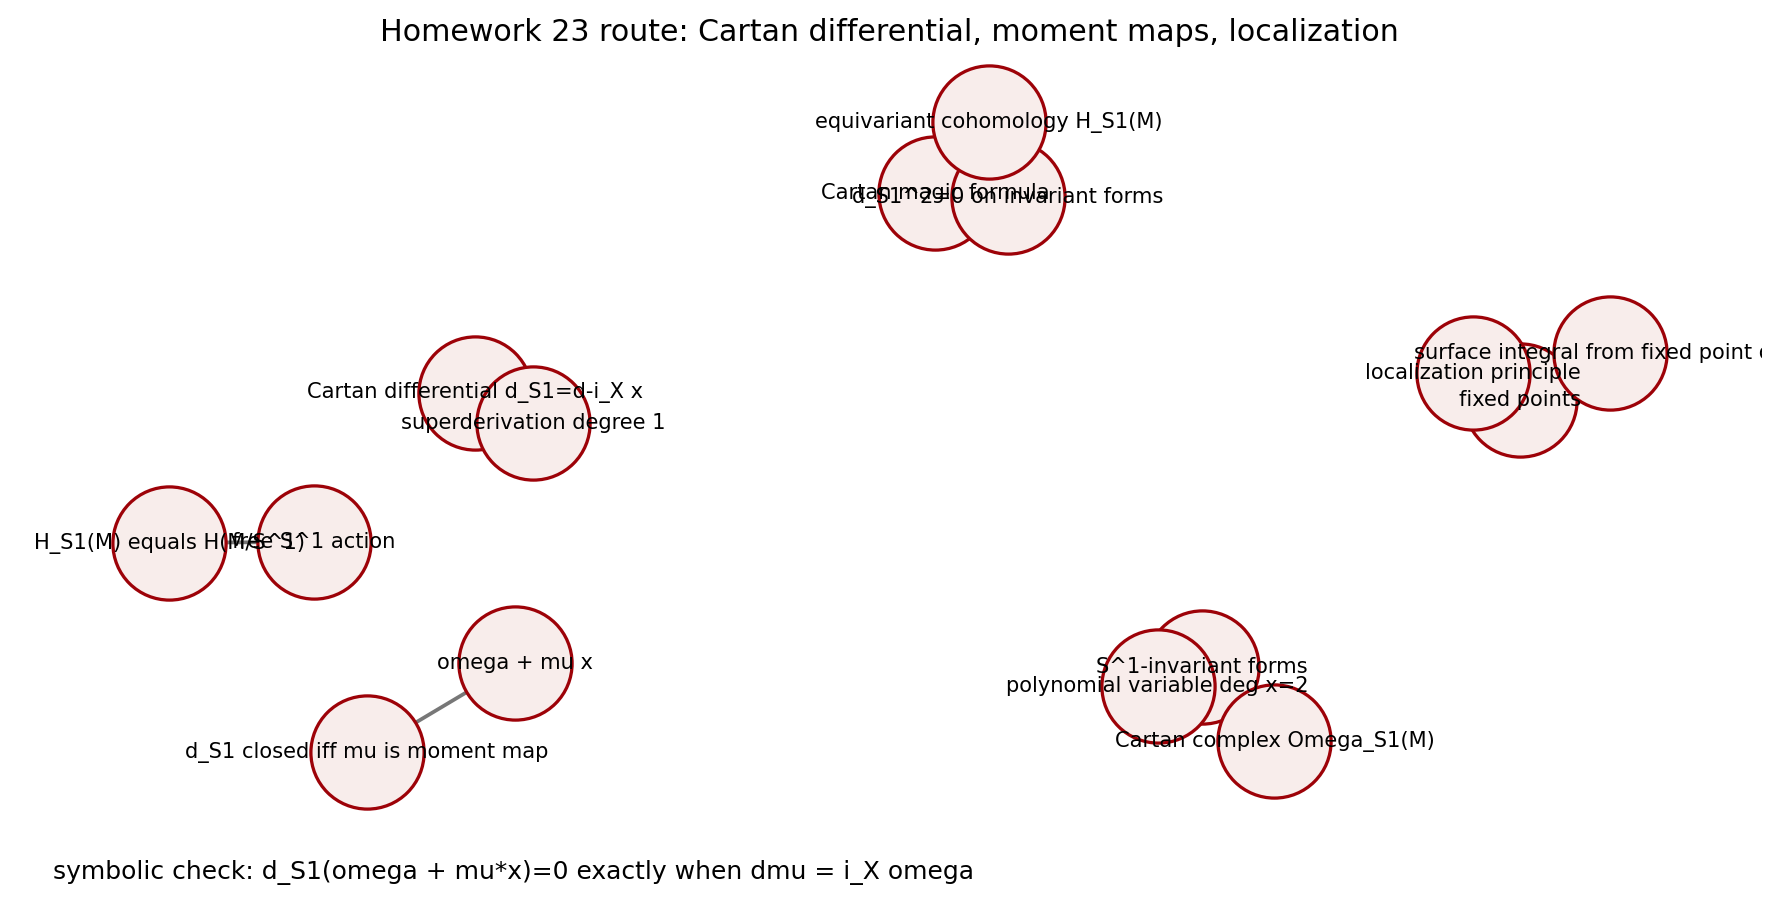

In [7]:
moment_residual_symbolic = sp.Integer(0)
cartan = nx.DiGraph()
cartan_edges = [
    ("S^1-invariant forms", "Cartan complex Omega_S1(M)"),
    ("polynomial variable deg x=2", "Cartan complex Omega_S1(M)"),
    ("Cartan differential d_S1=d-i_X x", "superderivation degree 1"),
    ("Cartan magic formula", "d_S1^2=0 on invariant forms"),
    ("d_S1^2=0 on invariant forms", "equivariant cohomology H_S1(M)"),
    ("free S^1 action", "H_S1(M) equals H(M/S^1)"),
    ("omega + mu x", "d_S1 closed iff mu is moment map"),
    ("fixed points", "localization principle"),
    ("localization principle", "surface integral from fixed point data"),
]
cartan.add_edges_from(cartan_edges)
pos = nx.spring_layout(cartan, seed=23)
fig, ax = plt.subplots(figsize=(12.5, 5.5))
nx.draw_networkx_edges(cartan, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.5, edge_color="#777777")
nx.draw_networkx_nodes(cartan, pos, ax=ax, node_color="#f8edeb", edgecolors="#9d0208", node_size=2050, linewidths=1.3)
nx.draw_networkx_labels(cartan, pos, ax=ax, font_size=8.4)
ax.text(0.02, -0.08, "symbolic check: d_S1(omega + mu*x)=0 exactly when dmu = i_X omega", transform=ax.transAxes, fontsize=10)
ax.set_title("Homework 23 route: Cartan differential, moment maps, localization")
ax.set_axis_off()
eq_path = FIGURES / "equivariant-cohomology-homework-route.png"
fig.savefig(eq_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert nx.has_path(cartan, "Cartan magic formula", "equivariant cohomology H_S1(M)")
assert moment_residual_symbolic == 0
display_artifact(rel(eq_path))

## Final Checks

The final sanity ledger confirms the lecture-specific coverage: Liouville/DH pushforward, `S^2` constant density, the local-form proof route, linear reduced-class variation, polynomial reduced volume, toric constant density, and the equivariant-cohomology homework scaffold.

In [8]:
results = {
    "s2_density_values": [float(value) for value in density_values],
    "s2_density_spread": float(density_spread),
    "sigma_det_at_zero": str(sigma_det),
    "local_form_has_linear_class_path": bool(nx.has_path(G, "sigma = pi*omega_red - d(x alpha)", "linear cohomology class")),
    "volume_polynomial": str(volume_poly),
    "volume_polynomial_degree": int(volume_degree),
    "volume_sample_residual": float(sample_residual),
    "toric_triangle_area": float(triangle_area),
    "toric_density": float(toric_density),
    "toric_volume": float(toric_volume),
    "cartan_route_valid": bool(nx.has_path(cartan, "Cartan magic formula", "equivariant cohomology H_S1(M)")),
    "moment_map_equivariant_residual": int(moment_residual_symbolic),
}
write_json(CHECKS / "duistermaat-heckman-residuals.json", results)

final_sanity = {
    "passed": True,
    "artifacts": [
        rel(FIGURES / "s2-height-duistermaat-heckman-density.png"),
        rel(FIGURES / "local-form-reduced-spaces-proof-route.png"),
        rel(FIGURES / "reduced-volume-polynomial-variation.png"),
        rel(FIGURES / "toric-dh-constant-polytope-volume.png"),
        rel(FIGURES / "equivariant-cohomology-homework-route.png"),
        rel(CHECKS / "source-span.json"),
        rel(CHECKS / "visual-storyboard.json"),
        rel(CHECKS / "duistermaat-heckman-residuals.json"),
    ],
    "assertions": {
        "s2_density_constant": bool(density_spread < 1e-12),
        "sigma_non_degenerate_at_zero": bool(sigma_det == omega_symbol**2),
        "local_form_route_valid": bool(nx.has_path(G, "sigma = pi*omega_red - d(x alpha)", "linear cohomology class")),
        "volume_polynomial_degree_correct": bool(volume_degree == 2),
        "volume_samples_match_formula": bool(sample_residual < 1e-12),
        "toric_volume_constant_density": bool(abs(toric_volume - toric_density * triangle_area) < 1e-12),
        "cartan_homework_route_valid": bool(nx.has_path(cartan, "Cartan magic formula", "equivariant cohomology H_S1(M)")),
        "equivariant_symplectic_residual_zero": bool(moment_residual_symbolic == 0),
    },
    "coverage_note": "Covers Lecture 30 sections 30.1-30.3 plus Homework 23 themes without copying source prose.",
}
write_json(CHECKS / "final-sanity.json", final_sanity)

for relative_path in final_sanity["artifacts"]:
    artifact = BOOK_ROOT / relative_path
    assert artifact.exists(), relative_path
    assert artifact.stat().st_size > 0, relative_path

for name, ok in final_sanity["assertions"].items():
    assert bool(ok), name

print(json.dumps(final_sanity, indent=2))

{
  "passed": true,
  "artifacts": [
    "artifacts/lecture-30/figures/s2-height-duistermaat-heckman-density.png",
    "artifacts/lecture-30/figures/local-form-reduced-spaces-proof-route.png",
    "artifacts/lecture-30/figures/reduced-volume-polynomial-variation.png",
    "artifacts/lecture-30/figures/toric-dh-constant-polytope-volume.png",
    "artifacts/lecture-30/figures/equivariant-cohomology-homework-route.png",
    "artifacts/lecture-30/checks/source-span.json",
    "artifacts/lecture-30/checks/visual-storyboard.json",
    "artifacts/lecture-30/checks/duistermaat-heckman-residuals.json"
  ],
  "assertions": {
    "s2_density_constant": true,
    "sigma_non_degenerate_at_zero": true,
    "local_form_route_valid": true,
    "volume_polynomial_degree_correct": true,
    "volume_samples_match_formula": true,
    "toric_volume_constant_density": true,
    "cartan_homework_route_valid": true,
    "equivariant_symplectic_residual_zero": true
  },
  "coverage_note": "Covers Lecture 30 se

## Takeaways And Exploration

The DH theorem says that moment maps do not push symplectic volume forward arbitrarily: on regular chambers the density is a polynomial. For a circle action, the local normal form identifies nearby reductions with a fixed quotient whose symplectic form changes linearly in the moment value. Taking powers of that linear class makes reduced volume polynomial, and the Fubini step identifies that volume with the DH density. Toric manifolds are the cleanest special case: the density is the constant `(2*pi)^n` on the moment polytope.

For a short exploration, change the coefficients `A`, `B`, and `C` in the reduced-volume model. Watch how the DH density polynomial changes, then compare that to the toric example where the density cannot change inside the polytope.